# PPE Detection Training Notebook — RT-DETR

**Goal:** Train and evaluate an RT-DETR object detection model on the PPE dataset.

This notebook is structured for final submission:
- Dataset checking and class statistics
- RT-DETR training
- Validation and testing
- Training curves and confusion matrix
- Prediction visualization on test images
- Exported model paths: `best.pt` and `last.pt`

> Before submitting: run all cells, save the notebook with visible outputs, and make sure the metrics in the LaTeX report match this notebook.


In [ ]:
!python -m pip install -U ultralytics roboflow pandas matplotlib pillow pyyaml opencv-python tqdm

In [ ]:
from pathlib import Path
import os
import random
import shutil
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as IPyImage

import torch
from ultralytics import RTDETR

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PROJECT_ROOT = Path(r"D:/Training + AI/PPE Train")

if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

DATASET_DIR = PROJECT_ROOT / "datasets" / "PPE-3"
DATA_YAML = DATASET_DIR / "data.yaml"

RUN_PROJECT = PROJECT_ROOT / "runs_rtdetr"
RUN_NAME = "rtdetr_ppe"
RTDETR_MODEL = "rtdetr-l.pt"  

EPOCHS = 50
IMGSZ = 640
BATCH = 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"
WORKERS = 0 

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_YAML:", DATA_YAML)
print("RUN_PROJECT:", RUN_PROJECT)
print("RTDETR_MODEL:", RTDETR_MODEL)


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3080
PROJECT_ROOT: D:\Training + AI\PPE Train
DATA_YAML: D:\Training + AI\PPE Train\datasets\PPE-3\data.yaml
RUN_PROJECT: D:\Training + AI\PPE Train\runs_rtdetr
RTDETR_MODEL: rtdetr-l.pt


## 2. Dataset loading

Use the existing YOLO-format dataset if `data.yaml` already exists.

If the dataset is not available locally, uncomment the Roboflow cell below and fill your API key/workspace/project/version.


In [ ]:
assert DATA_YAML.exists(), f"data.yaml not found: {DATA_YAML}"

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

print("data.yaml content:")
print(data_cfg)

names = data_cfg.get("names")
if isinstance(names, dict):
    class_names = [names[i] for i in sorted(names.keys())]
else:
    class_names = list(names)

num_classes = len(class_names)
print("\nNumber of classes:", num_classes)
print("Class names:", class_names)

for split in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"
    print(f"{split:5s} images:", len(list(img_dir.glob("*.*"))) if img_dir.exists() else "missing",
          "| labels:", len(list(label_dir.glob("*.txt"))) if label_dir.exists() else "missing")


data.yaml content:
{'names': ['Gloves', 'Goggles', 'Helmet', 'No-Gloves', 'No-Goggles', 'No-Helmet', 'Person'], 'nc': 7, 'roboflow': {'license': 'Public Domain', 'project': 'ppe-8k2vo', 'url': 'https://universe.roboflow.com/ppe-ihvqu/ppe-8k2vo/dataset/3', 'version': 3, 'workspace': 'ppe-ihvqu'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Number of classes: 7
Class names: ['Gloves', 'Goggles', 'Helmet', 'No-Gloves', 'No-Goggles', 'No-Helmet', 'Person']
train images: 8160 | labels: 8160
valid images: 905 | labels: 905
test  images: 903 | labels: 903


,split,total_boxes,Gloves,Goggles,Helmet,No-Gloves,No-Goggles,No-Helmet,Person
0,train,35238,5206,3819,8178,2526,1153,2489,11867
1,valid,3819,535,418,900,269,130,264,1303
2,test,3823,543,432,936,244,117,235,1316


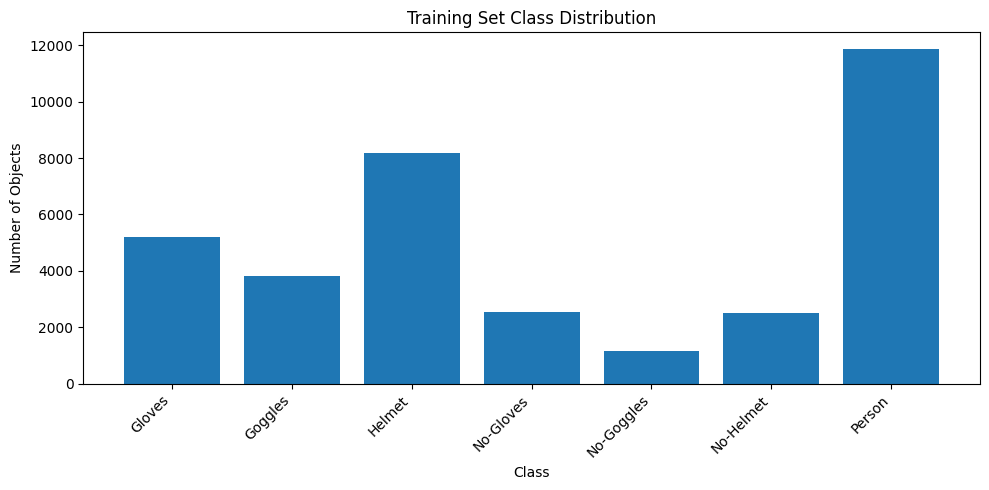

In [ ]:
def count_yolo_labels(label_dir: Path, n_classes: int):
    counts = [0] * n_classes
    total_boxes = 0
    if not label_dir.exists():
        return counts, total_boxes

    for txt in label_dir.glob("*.txt"):
        lines = txt.read_text(encoding="utf-8").strip().splitlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(float(parts[0]))
                if 0 <= cls_id < n_classes:
                    counts[cls_id] += 1
                    total_boxes += 1
    return counts, total_boxes

stats = []
for split in ["train", "valid", "test"]:
    counts, total_boxes = count_yolo_labels(DATASET_DIR / split / "labels", num_classes)
    row = {"split": split, "total_boxes": total_boxes}
    for i, name in enumerate(class_names):
        row[name] = counts[i]
    stats.append(row)

df_stats = pd.DataFrame(stats)
display(df_stats)

train_counts = df_stats[df_stats["split"] == "train"][class_names].iloc[0]
plt.figure(figsize=(10, 5))
plt.bar(class_names, train_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()


## 4. Train RT-DETR

The training output will be saved under:

```text
runs_rtdetr/rtdetr_ppe/
├── weights/best.pt
├── weights/last.pt
├── results.csv
├── results.png
├── confusion_matrix.png
└── ...
```

For RTX 3080 10GB, start with `rtdetr-l.pt`, `imgsz=640`, `batch=4`, and `workers=0` on Windows.


In [ ]:
model = RTDETR(RTDETR_MODEL)

train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project=str(RUN_PROJECT),
    name=RUN_NAME,
    exist_ok=True,
    pretrained=True,
    optimizer="AdamW",
    lr0=1e-4,
    weight_decay=5e-4,
    amp=True,
    cache=False,
    plots=True,
    val=True,
    patience=15,
)

RUN_DIR = RUN_PROJECT / RUN_NAME
BEST_PT = RUN_DIR / "weights" / "best.pt"
LAST_PT = RUN_DIR / "weights" / "last.pt"

print("Training finished.")
print("Run directory:", RUN_DIR)
print("best.pt:", BEST_PT, "| exists:", BEST_PT.exists())
print("last.pt:", LAST_PT, "| exists:", LAST_PT.exists())


Ultralytics 8.4.60  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 10240MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Training + AI\PPE Train\datasets\PPE-3\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_ppe, nbs=64, nms=False, opset=None, optimize=False, optimizer=

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      5.83G      1.095     0.8059     0.4681          2       1280: 100% ━━━━━━━━━━━━ 4080/4080 2.2it/s 31:30<0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 227/227 8.2it/s 27.8s<0.1s
                   all        905       3819      0.484      0.189     0.0711     0.0338

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      6.12G     0.4701      1.234     0.1143          2       1280: 0% ──────────── 0/4080  0.6s

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      6.12G     0.6954      1.026     0.2338          2       1280: 100% ━━━━━━━━━━━━ 4080/4080 2.2it/s 30:26<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 227/227 12.5it/s 18.1s0.2s
                   all        905       3819      0.516      0.244      0.113     0.0655

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      6.11G     0.6192     0.9508     0.1468          2       1280: 0% ──────────── 0/4080  0.5s

...

      48/50       2.2G     0.2413     0.3758     0.1683          2        640: 100% ━━━━━━━━━━━━ 4080/4080 3.8it/s 18:01<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 227/227 12.5it/s 18.1s<0.1s
                   all        905       3819      0.659      0.634       0.62      0.477

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      49/50       2.2G     0.3437     0.4597     0.1599          2        640: 0% ──────────── 0/4080  0.3s

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50       2.2G     0.2395     0.3707     0.1641          2        640: 100% ━━━━━━━━━━━━ 4080/4080 3.7it/s 18:19<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 227/227 12.3it/s 18.5s<0.1s
                   all        905       3819      0.663      0.628      0.619      0.478

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50       2.2G     0.4276     0.3123     0.3692          2        640: 0% ──────────── 0/4080  0.3s

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50       2.2G     0.2387     0.3681     0.1652          2        640: 100% ━━━━━━━━━━━━ 4080/4080 3.7it/s 18:14<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 227/227 12.3it/s 18.4s0.2s
                   all        905       3819      0.652      0.637      0.619      0.475

50 epochs completed in 24.464 hours.
Optimizer stripped from D:\Training + AI\PPE Train\runs_rtdetr\rtdetr_ppe\weights\last.pt, 66.2MB
Optimizer stripped from D:\Training + AI\PPE Train\runs_rtdetr\rtdetr_ppe\weights\best.pt, 66.2MB

Validating D:\Training + AI\PPE Train\runs_rtdetr\rtdetr_ppe\weights\best.pt...
Ultralytics 8.4.60  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 10240MiB)
rt-detr-l summary: 310 layers, 31,998,125 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 227/227 13.8it/s 16.5s<0.1s
                   all 

In [7]:
# ============================================================
# 5. VALIDATE BEST MODEL ON VALIDATION SET
# ============================================================
assert BEST_PT.exists(), f"best.pt not found: {BEST_PT}"

best_model = RTDETR(str(BEST_PT))

val_metrics = best_model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
)

print("Validation metrics object:")
print(val_metrics)

# Common summary values
try:
    print("mAP50-95:", float(val_metrics.box.map))
    print("mAP50:", float(val_metrics.box.map50))
    print("mAP75:", float(val_metrics.box.map75))
    print("Precision:", float(val_metrics.box.mp))
    print("Recall:", float(val_metrics.box.mr))
except Exception as e:
    print("Could not extract all metrics automatically:", e)


Ultralytics 8.4.60  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 10240MiB)
rt-detr-l summary: 310 layers, 31,998,125 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 250.041.8 MB/s, size: 52.8 KB)
val: Scanning D:\Training + AI\PPE Train\datasets\PPE-3\valid\labels.cache... 905 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 905/905  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 453/453 20.0it/s 22.7s<0.1s
                   all        905       3819       0.65      0.656      0.629      0.479
                Gloves        319        535      0.791      0.746        0.8      0.644
               Goggles        360        418      0.766      0.775      0.787      0.591
                Helmet        421        900      0.832      0.871      0.864      0.694
             No-Gloves        195        269      0.453      0.375      0.303      0.184
            No-

In [8]:
# ============================================================
# 6. TEST BEST MODEL ON TEST SET
# ============================================================
test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
)

print("Test metrics object:")
print(test_metrics)

try:
    test_summary = {
        "model": RTDETR_MODEL,
        "mAP50-95": float(test_metrics.box.map),
        "mAP50": float(test_metrics.box.map50),
        "mAP75": float(test_metrics.box.map75),
        "Precision": float(test_metrics.box.mp),
        "Recall": float(test_metrics.box.mr),
    }
    df_test_summary = pd.DataFrame([test_summary])
    display(df_test_summary)
    df_test_summary.to_csv(RUN_DIR / "test_summary_rtdetr.csv", index=False)
    print("Saved:", RUN_DIR / "test_summary_rtdetr.csv")
except Exception as e:
    print("Could not create test summary:", e)


Ultralytics 8.4.60  Python-3.11.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 10240MiB)
rt-detr-l summary: 310 layers, 31,998,125 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 6.21.7 MB/s, size: 63.6 KB)
val: Scanning D:\Training + AI\PPE Train\datasets\PPE-3\test\labels.cache... 903 images, 24 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 903/903  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 452/452 15.4it/s 29.4s<0.1s
                   all        903       3823      0.633      0.653      0.619      0.477
                Gloves        309        543      0.782      0.759      0.804      0.639
               Goggles        354        432      0.779      0.799      0.812      0.609
                Helmet        436        936      0.804      0.854       0.84       0.67
             No-Gloves        178        244      0.414       0.34      0.261      0.181
            No-Gogg

,model,mAP50-95,mAP50,mAP75,Precision,Recall
0,rtdetr-l.pt,0.476627,0.619416,0.518106,0.632838,0.653199


Saved: D:\Training + AI\PPE Train\runs_rtdetr\rtdetr_ppe\test_summary_rtdetr.csv


Displaying: results.png


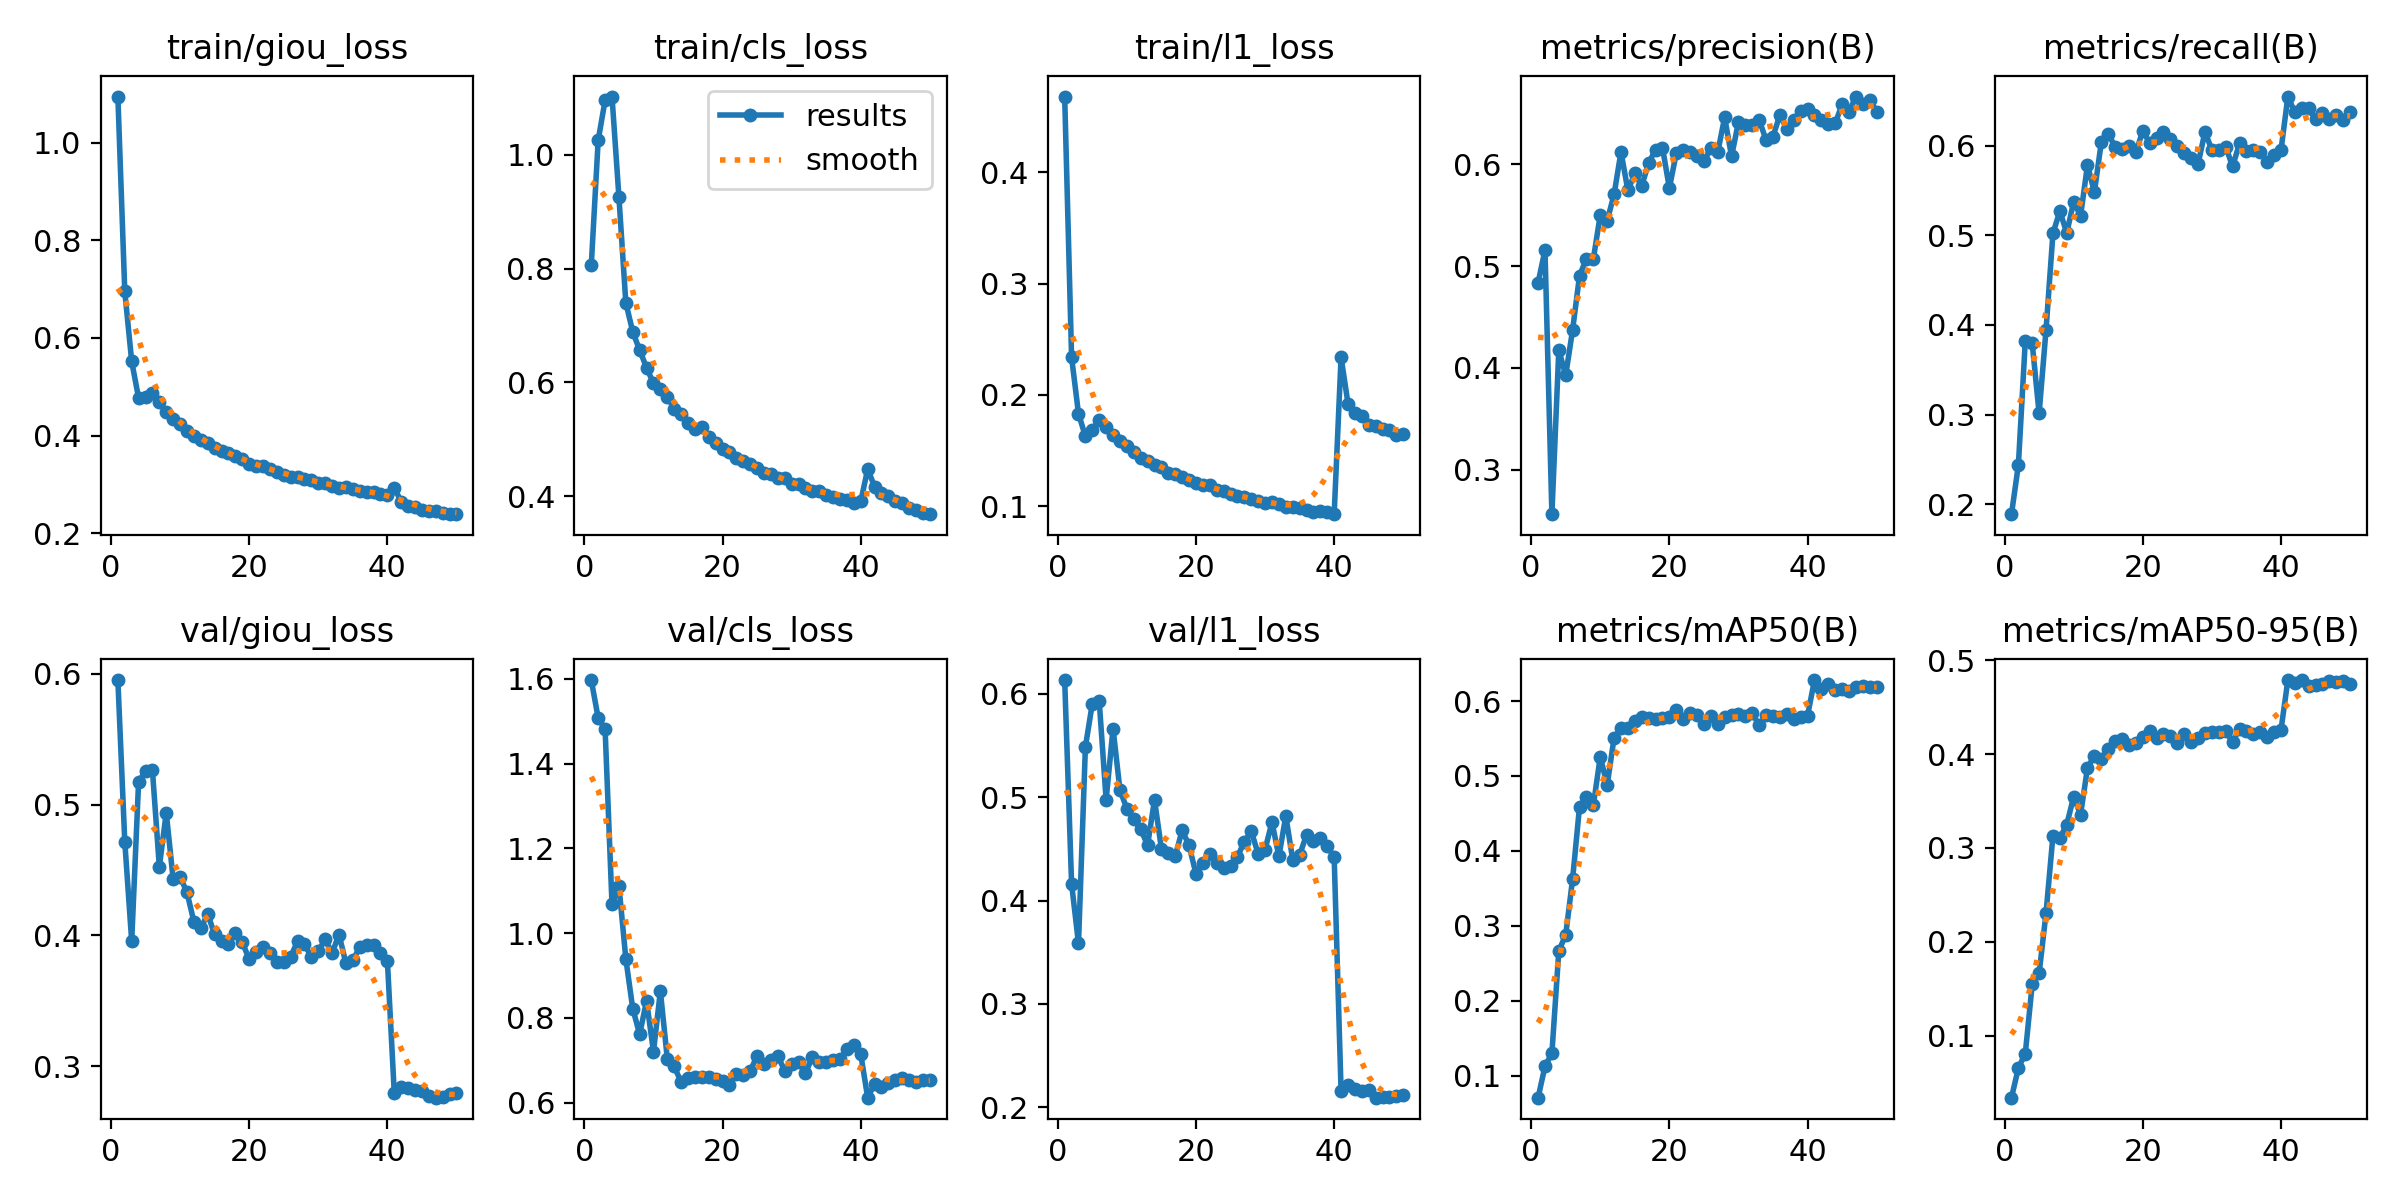

Displaying: confusion_matrix.png


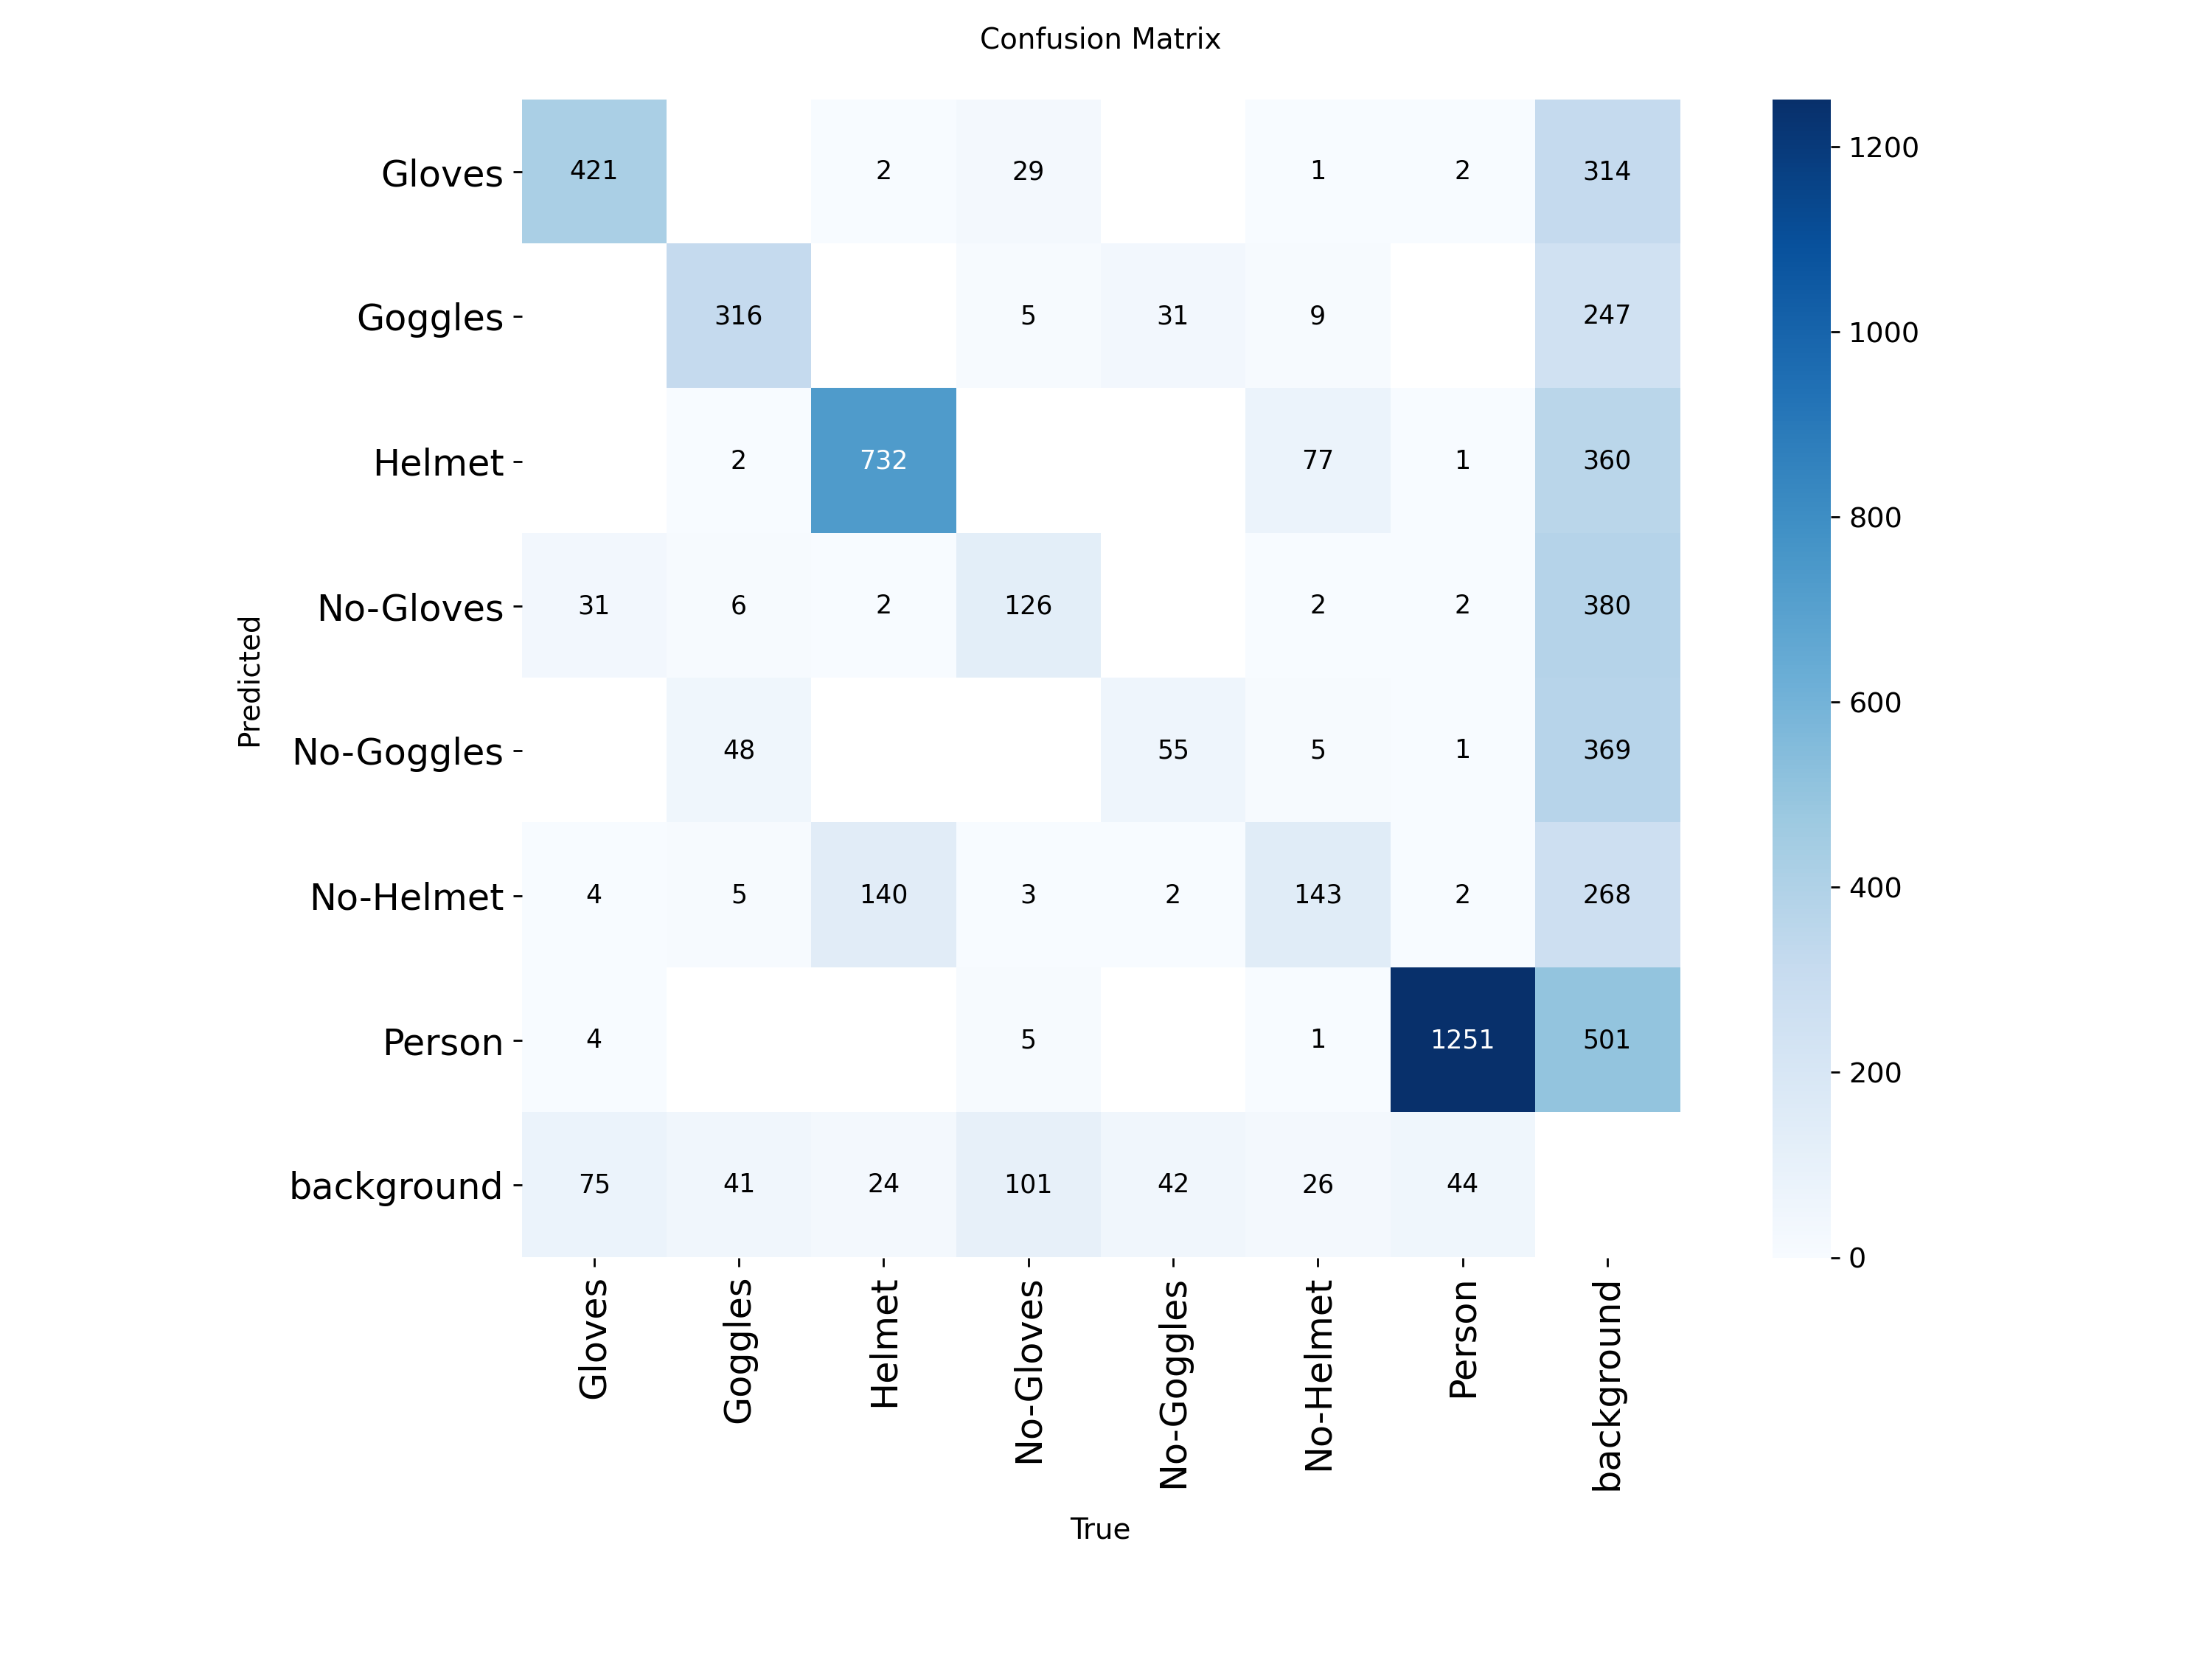

Displaying: confusion_matrix_normalized.png


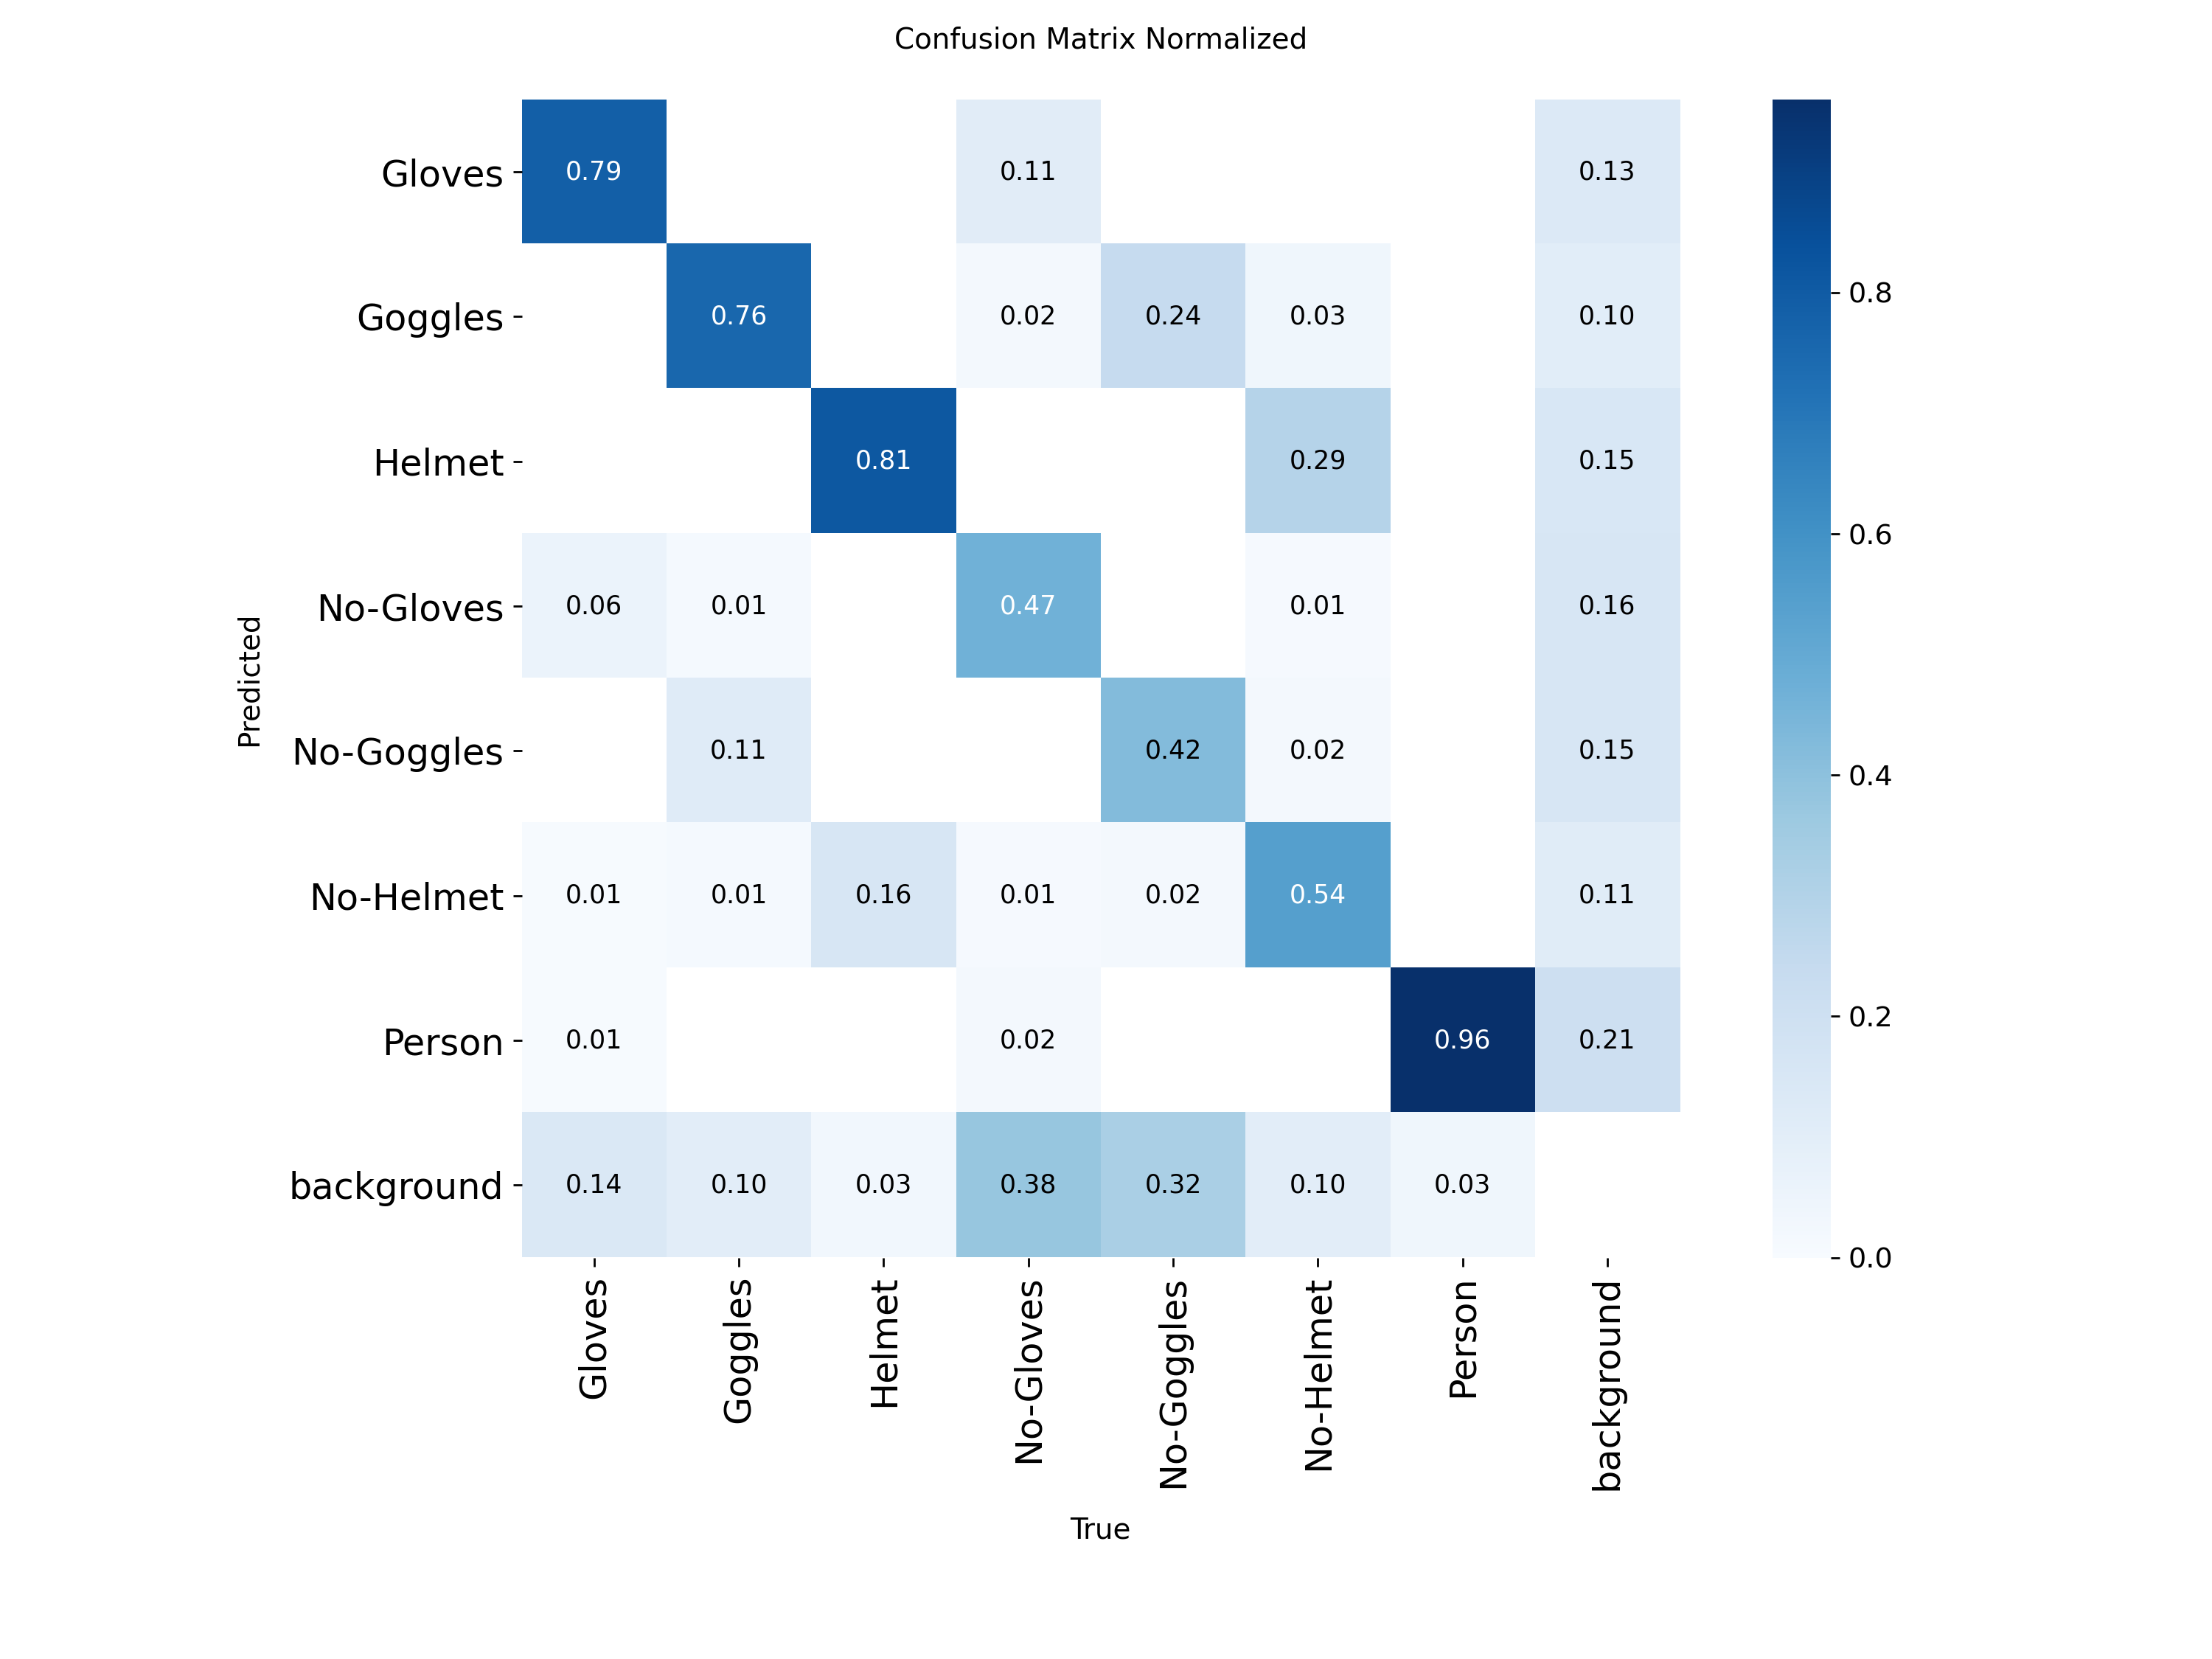

Missing: PR_curve.png
Missing: P_curve.png
Missing: R_curve.png
Missing: F1_curve.png


In [ ]:
figure_candidates = [
    RUN_DIR / "results.png",
    RUN_DIR / "confusion_matrix.png",
    RUN_DIR / "confusion_matrix_normalized.png",
    RUN_DIR / "PR_curve.png",
    RUN_DIR / "P_curve.png",
    RUN_DIR / "R_curve.png",
    RUN_DIR / "F1_curve.png",
]

for fig_path in figure_candidates:
    if fig_path.exists():
        print("Displaying:", fig_path.name)
        display(IPyImage(filename=str(fig_path)))
    else:
        print("Missing:", fig_path.name)


In [ ]:
results_csv = RUN_DIR / "results.csv"

assert results_csv.exists(), f"results.csv not found: {results_csv}"

df_results = pd.read_csv(results_csv)
display(df_results.tail())

# Save final epoch row for report comparison
final_row = df_results.tail(1).copy()
final_row.to_csv(RUN_DIR / "final_epoch_metrics_rtdetr.csv", index=False)
print("Saved final metrics:", RUN_DIR / "final_epoch_metrics_rtdetr.csv")


,epoch,time,train/giou_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/giou_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
45,46,83624.6,0.24600,0.38832,0.17174,0.65187,0.63583,0.61397,0.47469,0.27695,0.65724,0.20928,0.000011,0.000011,0.000011
46,47,84735.9,0.24460,0.37840,0.16974,0.66667,0.62964,0.61920,0.47763,0.27603,0.65327,0.21023,0.000009,0.000009,0.000009
47,48,85836.7,0.24126,0.37579,0.16828,0.65911,0.63397,0.61991,0.47748,0.27650,0.64841,0.20998,0.000007,0.000007,0.000007
48,49,86955.6,0.23954,0.37074,0.16411,0.66345,0.62825,0.61919,0.47776,0.27874,0.65391,0.21099,0.000005,0.000005,0.000005
49,50,88070.0,0.23870,0.36814,0.16522,0.65169,0.63727,0.61915,0.47531,0.27969,0.65321,0.21232,0.000003,0.000003,0.000003


Saved final metrics: D:\Training + AI\PPE Train\runs_rtdetr\rtdetr_ppe\final_epoch_metrics_rtdetr.csv


In [ ]:
TEST_IMAGES = DATASET_DIR / "test" / "images"
assert TEST_IMAGES.exists(), f"Test image folder not found: {TEST_IMAGES}"

predict_results = best_model.predict(
    source=str(TEST_IMAGES),
    imgsz=IMGSZ,
    conf=0.25,
    iou=0.7,
    device=DEVICE,
    save=True,
    project=str(RUN_PROJECT),
    name="rtdetr_ppe_test_predictions",
    exist_ok=True,
)

PRED_DIR = RUN_PROJECT / "rtdetr_ppe_test_predictions"
print("Prediction output directory:", PRED_DIR)



image 1/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\00014_jpg.rf.fa33a09a66f6eb8df994874ccc7827bc.jpg: 640x640 1 Helmet, 1 No-Gloves, 2 No-Goggless, 2 No-Helmets, 2 Persons, 24.7ms
image 2/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\00020_jpg.rf.f89a79028615b714d2201f601f91b0e6.jpg: 640x640 1 Gloves, 4 No-Glovess, 3 Persons, 24.9ms
image 3/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\00022_jpg.rf.80ae870a90f464ef0e792eb84c80bc55.jpg: 640x640 1 Gloves, 2 No-Glovess, 1 No-Goggles, 1 No-Helmet, 1 Person, 25.4ms
image 4/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\000240_jpeg.rf.8fa0b890a19233c10359582e7dd3ab8a.jpg: 640x640 1 Goggles, 1 Helmet, 1 Person, 27.4ms
image 5/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\00085_jpg.rf.b59504fd39c522797b95da7c47f29ea5.jpg: 640x640 1 No-Gloves, 3 No-Goggless, 1 No-Helmet, 1 Person, 32.9ms
image 6/903 D:\Training + AI\PPE Train\datasets\PPE-3\test\images\000915_jpeg.rf.3d29780328f72dd

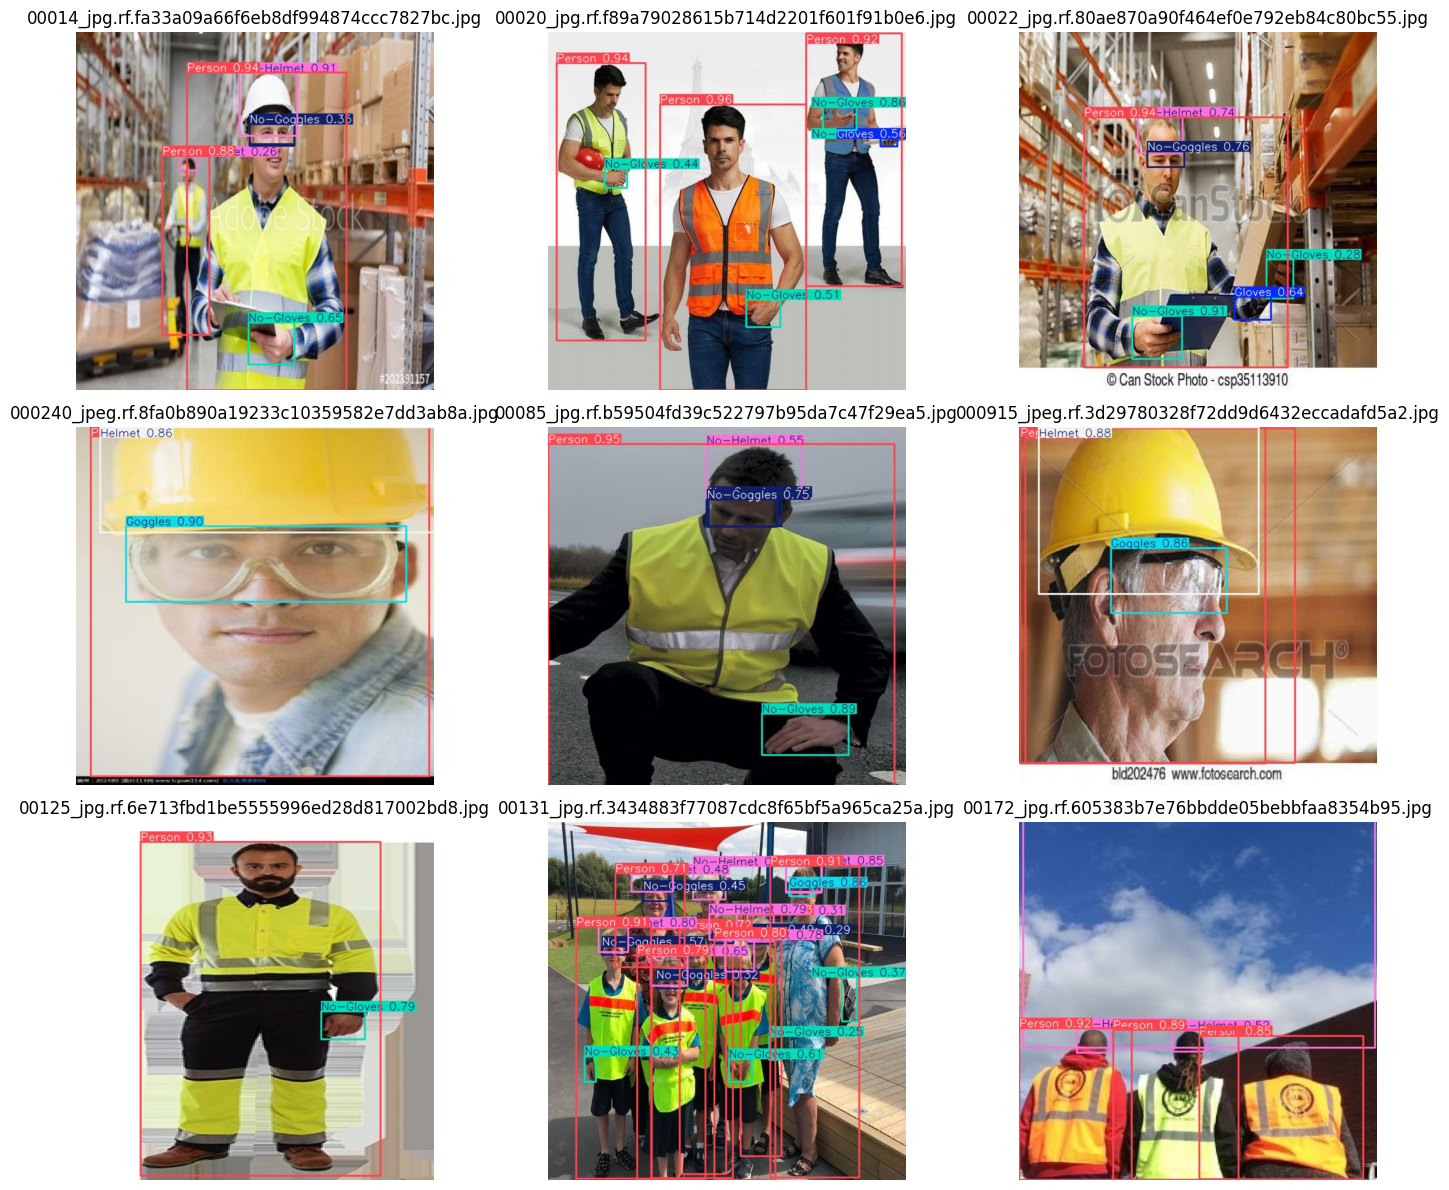

In [ ]:
def display_image_grid(image_paths, max_images=9, cols=3):
    image_paths = list(image_paths)[:max_images]
    if not image_paths:
        print("No prediction images found.")
        return

    rows = (len(image_paths) + cols - 1) // cols
    plt.figure(figsize=(cols * 5, rows * 4))

    for i, img_path in enumerate(image_paths):
        img = Image.open(img_path).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

pred_images = sorted([p for p in PRED_DIR.glob("*.*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
display_image_grid(pred_images, max_images=9, cols=3)


In [ ]:
print("Use these files:")
print("best.pt for web/demo:", BEST_PT)
print("last.pt for resume training:", LAST_PT)

# Optional: copy weights into a clean submission folder
SUBMISSION_DIR = PROJECT_ROOT / "submission_artifacts" / "rtdetr"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

if BEST_PT.exists():
    shutil.copy2(BEST_PT, SUBMISSION_DIR / "best.pt")
if LAST_PT.exists():
    shutil.copy2(LAST_PT, SUBMISSION_DIR / "last.pt")
if results_csv.exists():
    shutil.copy2(results_csv, SUBMISSION_DIR / "results.csv")

print("Copied artifacts to:", SUBMISSION_DIR)


Use these files:
best.pt for web/demo: D:\Training + AI\PPE Train\runs_rtdetr\rtdetr_ppe\weights\best.pt
last.pt for resume training: D:\Training + AI\PPE Train\runs_rtdetr\rtdetr_ppe\weights\last.pt
Copied artifacts to: D:\Training + AI\PPE Train\submission_artifacts\rtdetr


## Submission checklist

Before uploading to MS Teams, make sure the following are included:

1. LaTeX report source + compiled PDF.
2. This `.ipynb` notebook with all outputs visible.
3. RT-DETR weights:
   - `best.pt`
   - `last.pt`
4. Result files:
   - `results.csv`
   - `confusion_matrix.png`
   - `results.png`
   - sample prediction images
5. Presentation slides: `.pptx` or `.pdf`.

Important: the numbers in the report must match the notebook outputs.
